# Эксперимент 2.5
Микропрофилирование (`лаб2.pdf`, п. 2.5).


In [1]:
%load_ext autoreload
%autoreload 2


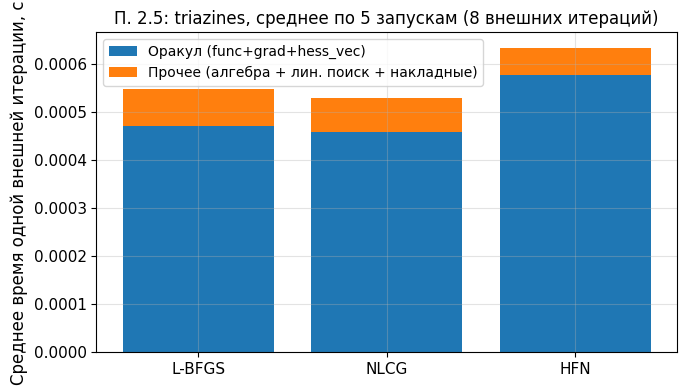

In [2]:
%matplotlib inline
import sys
import time
from pathlib import Path

_root = Path.cwd().resolve()
if _root.name == "notebooks":
    _root = _root.parent
_src = _root / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import matplotlib.pyplot as plt
import numpy as np
from experiments_common import (
    TimedOracle,
    init_notebook,
    load_a1a,
    load_triazines,
    make_classification_oracle,
    make_regression_oracle,
    savefig_both,
    standard_regcoef,
    train_test_oracles_regression,
)
from ml_tools import sparse_oracle_ops
from optimization import (
    gradient_descent,
    hessian_free_newton,
    lbfgs,
    newton,
    newton_modified,
    nonlinear_conjugate_gradients,
    trust_region_steihaug_newton,
)
from oracles import NonConvexOracle, QuadraticOracle, beale_mesh_Z

init_notebook()

Xr, yr = load_triazines()
oracle = make_regression_oracle(Xr, yr, standard_regcoef(Xr.shape[0]))
n = Xr.shape[1]
x0 = np.zeros(n)
line = {"method": "Wolfe", "alpha_0": 1.0}


def avg_profile(name, inner):
    ot = 0.0
    wt = 0.0
    reps = 5
    for _ in range(reps):
        o = TimedOracle(oracle)
        t0 = time.perf_counter()
        inner(o)
        wt += time.perf_counter() - t0
        ot += o.t_func + o.t_grad + o.t_hess_vec
    ot /= reps
    wt /= reps
    return name, ot, max(wt - ot, 0.0)


rows = [
    avg_profile(
        "L-BFGS",
        lambda o: lbfgs(
            o,
            x0,
            tolerance=1e-2,
            max_iter=8,
            memory_size=10,
            line_search_options=line,
            trace=False,
        ),
    ),
    avg_profile(
        "NLCG",
        lambda o: nonlinear_conjugate_gradients(
            o,
            x0,
            tolerance=1e-2,
            max_iter=8,
            line_search_options=line,
            trace=False,
        ),
    ),
    avg_profile(
        "HFN",
        lambda o: hessian_free_newton(
            o,
            x0,
            tolerance=1e-2,
            max_iter=8,
            line_search_options=line,
            trace=False,
        ),
    ),
]
names = [r[0] for r in rows]
ora = [r[1] for r in rows]
rest = [max(r[2], 0.0) for r in rows]
fig, ax = plt.subplots(figsize=(7, 4))
xpos = np.arange(len(names))
ax.bar(xpos, ora, label="Оракул (func+grad+hess_vec)")
ax.bar(xpos, rest, bottom=ora, label="Прочее (алгебра + лин. поиск + накладные)")
ax.set_xticks(xpos)
ax.set_xticklabels(names)
ax.set_ylabel("Среднее время одной внешней итерации, с")
ax.set_title("П. 2.5: triazines, среднее по 5 запускам (8 внешних итераций)")
ax.legend()
fig.tight_layout()
savefig_both(fig, "exp25_micro_profile")
plt.show()
